# What does a typical order look like?

**Week 1, Monday. Round 3 of 3: what is the typical Kalpa order, and which "typical" is honest?**

Marketing's case for Rs 12 crore values every new customer by the order they will place. Meera
Raghavan, the CEO, wants to know what that order is worth before she signs, and Anand Iyer, the
finance controller, has already told the room how he will read the answer:

> Meera: "What does a typical order look like?"
> Anand: "No averages. One business customer can move an average."

> **Kavya's review.** When you tell Meera what a typical order is worth, tell her which middle you
> used and why. If one order can move your number, it is describing that order rather than the
> business.

Round 2 established the customer branches: 23 customers placed 1.30 orders each, 7 of them came
back, and the tree multiplies back to Rs 5,44,810 through an average order value of Rs 18,160. This
round asks whether that Rs 18,160 describes an order anybody at Kalpa would recognise.

**Setup.** The first cell finds the shared helper, `c2kit`, by walking up from this folder until it
reaches `scripts/`, then loads the 30 orders from `../data/` as `ORDERS`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()
amounts = []
for order in ORDERS:
    amounts.append(int(order["amount"]))
print(len(amounts), "amounts read, each converted with int() as round 2 taught")

30 amounts read, each converted with int() as round 2 taught


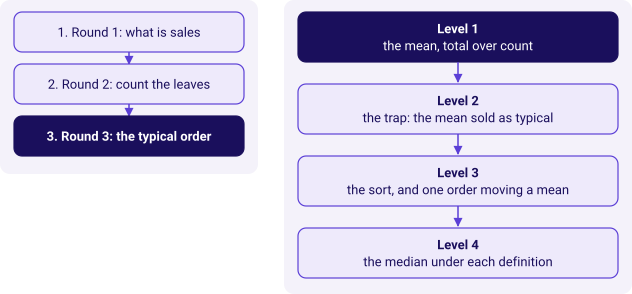

In [2]:
kit.side_by_side(
    kit.ladder(["Round 1: what is sales", "Round 2: count the leaves", "Round 3: the typical order"],
               lit=2, show=False),
    kit.vflow(["Level 1\nthe mean, total over count",
               "Level 2\nthe trap: the mean sold as typical",
               "Level 3\nthe sort, and one order moving a mean",
               "Level 4\nthe median under each definition"], lit=0, show=False),
)

## 1. The mean is the total divided by the count

The mean is the average most people mean when they say "average": add every amount, then divide by
how many there are. It is also the average order value in round 1's tree, which is why it multiplies
back to revenue so neatly.

**Predict before you run.** Booked revenue is Rs 5,44,810 on 30 orders. What is the mean order?

- a) Rs 18,160.
- b) About Rs 2,200, the size most orders are.
- c) Rs 23,687, revenue divided by the 23 customers.
- d) Rs 25,943, revenue divided by the 21 delivered orders.

mean order: Rs 18,160


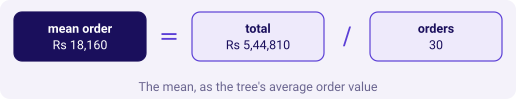

In [3]:
total = 0
count = 0
for amount in amounts:
    total += amount
    count += 1
mean = total / count
print("mean order:", kit.rupees(mean))
kit.equation(["mean order\n" + kit.rupees(mean), "=", "total\n" + kit.rupees(total), "/", f"orders\n{count}"],
             title="The mean, as the tree's average order value")

**What happened.** The answer is a. Rs 5,44,810 over 30 orders is Rs 18,160. Option c divides by
customers, which gives revenue per customer, a different branch; option d mixes the booked total
with the delivered count, so its numerator and denominator come from two definitions.

In [4]:
kit.check("the total is booked revenue", total == 544810, kit.rupees(total))
kit.check("the mean is Rs 18,160", round(mean) == 18160, kit.rupees(mean))
kit.check("mean times count gives the total back", round(mean * count) == total)

## 2. The trap: the mean sold as the typical order

Marketing's model credits each new customer's first order with the average order value. The slide
reads cleanly and the arithmetic is right, which is what makes it dangerous.

**Predict before you run.** How many of the 30 orders are larger than the mean of Rs 18,160?

- a) About 15, half of them, since the mean is the middle.
- b) 29 of them, since the mean sits low.
- c) One of them.
- d) None of them, since the mean is the largest value.

**The plausible wrong answer.** The number as it appears on marketing's slide:

In [5]:
typical_order = mean
print("A typical Kalpa order:", kit.rupees(typical_order))
print("What each new customer's first order is worth, per the model:", kit.rupees(typical_order))

A typical Kalpa order: Rs 18,160
What each new customer's first order is worth, per the model: Rs 18,160


**Why it is wrong.** A typical order is one that most orders look like. If nearly every order sits
below the mean, the mean is describing something else: one order at the top of the list pulls the
total, and so the mean, far above everything else. Valued at Rs 18,160, a new customer looks eight
times more valuable than the orders Kalpa actually takes, and Rs 12 crore looks cheap. The check
counts the orders on each side of the mean and draws every amount as a dot.

1 order above the mean, 29 below it


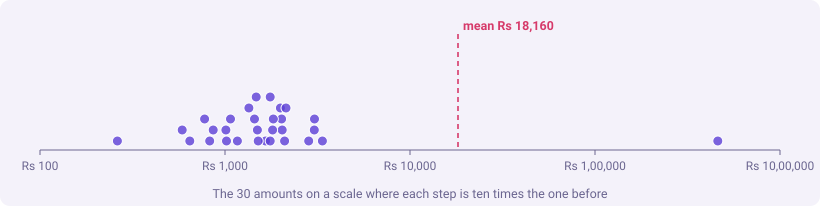

In [6]:
import math
above = 0
below = 0
for amount in amounts:
    if amount > mean:
        above += 1
    else:
        below += 1
print(above, "order above the mean,", below, "below it")
kit.strip([math.log10(a) for a in amounts], markers=[("mean", math.log10(mean), "bad")],
          lo=2, hi=6, fmt=lambda v: kit.rupees(round(10 ** v)),
          title="The 30 amounts on a scale where each step is ten times the one before")

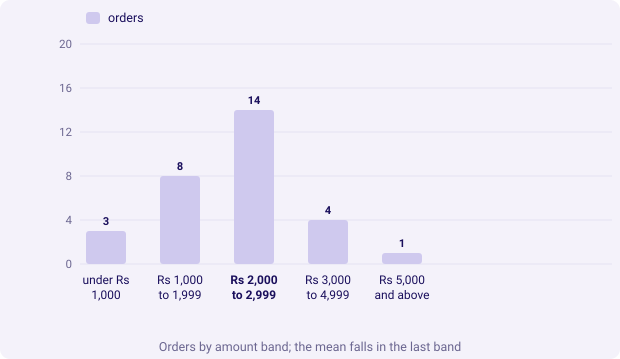

In [7]:
bands = ["under Rs 1,000", "Rs 1,000 to 1,999", "Rs 2,000 to 2,999", "Rs 3,000 to 4,999", "Rs 5,000 and above"]
limits = [1000, 2000, 3000, 5000]
in_band = [0, 0, 0, 0, 0]
for amount in amounts:
    slot = 0
    while slot < len(limits) and amount >= limits[slot]:
        slot += 1
    in_band[slot] += 1
kit.columns(bands, [("orders", in_band)], lit=(2,), width=620,
            title="Orders by amount band; the mean falls in the last band")
kit.check("exactly one order sits above the mean", above == 1, above)
kit.check("29 of 30 orders sit below the mean", below == 29, below)
kit.check("the bands hold all 30 orders", sum(in_band) == 30, in_band)

**What happened.** The answer is c. One order sits above Rs 18,160 and 29 sit below it; on the strip
the dots pile up below Rs 5,000 while the mean line stands well to the right of the
pile. The mean is correct arithmetic and a poor description of a Kalpa order.

**The fix.** Report a middle that one order cannot drag: the median, the value with half the orders
below it and half above. With 30 orders there are two middle values, the 15th and 16th in size
order, and the median is halfway between them.

the two middle orders: Rs 2,110 and Rs 2,300
median order: Rs 2,205 | mean order: Rs 18,160 | the mean is 8.2 times the median


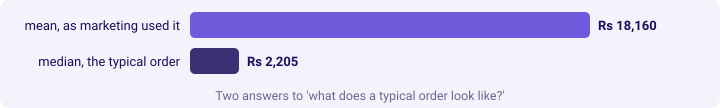

In [8]:
ranked = sorted(amounts)
lower_middle, upper_middle = ranked[14], ranked[15]
median = (lower_middle + upper_middle) / 2
print("the two middle orders:", kit.rupees(lower_middle), "and", kit.rupees(upper_middle))
print("median order:", kit.rupees(median), "| mean order:", kit.rupees(mean),
      f"| the mean is {mean / median:.1f} times the median")
kit.bars([("mean, as marketing used it", round(mean)), ("median, the typical order", round(median))],
         fmt=kit.rupees, lit=(1,), title="Two answers to 'what does a typical order look like?'")
kit.check("the median is Rs 2,205", median == 2205, kit.rupees(median))
kit.check("the median is about one eighth of the mean", 8 <= mean / median <= 8.5, f"{mean / median:.2f}")

What changed: the typical order falls from Rs 18,160 to Rs 2,205, about one eighth. A new customer's
first order is worth about Rs 2,205, so an acquisition plan has to earn back its cost over roughly
eight times as many orders as the mean suggested.

> **Kavya's review.** Anand said "no averages" and you now know why. Put the median in the sentence,
> say that the mean is eight times higher, and say that one order does it. Then go and find that
> order.

## 3. One order at the top of the sort moves the mean and leaves the median

Level 2 showed that one order sits above the mean. The way to meet it is to sort the amounts and
read the top of the list, then find the record the top amount belongs to.

**Your turn.** Type these lines into the empty cell below and run it:

```python
ranked = sorted(amounts)
print("smallest three:", ranked[:3])
print("largest three:", ranked[-3:])
```

**Your turn.** Now find the order behind the largest amount. Type these lines into the next empty
cell, run it, and say in one sentence what kind of order it is and whether it belongs in a typical
order:

```python
top = ranked[-1]
for order in ORDERS:
    if int(order["amount"]) == top:
        print(order)
```

The mechanism is easier to see on a handful of numbers. The records below are **invented** for this
demonstration and are not Kalpa orders: five invented orders between Rs 1,900 and Rs 2,600, and one
invented order of Rs 90,000 added to them.

**Predict before you run.** When the invented Rs 90,000 order joins the five, which moves more?

- a) The median, because the middle shifts along by one.
- b) Both, by the same amount.
- c) Neither, because one order out of six is small.
- d) The mean, because it adds every rupee of the new order.

invented records,mean,median
five invented orders,"Rs 2,240","Rs 2,200"
"the same five plus one invented Rs 90,000 order","Rs 16,867","Rs 2,300"


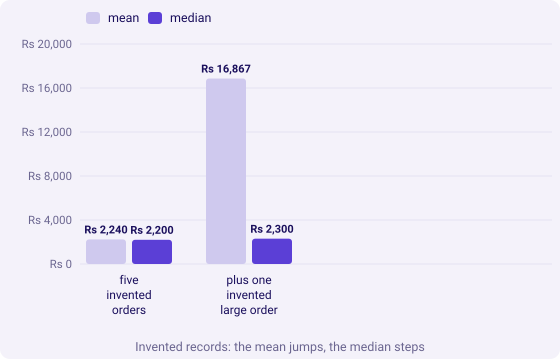

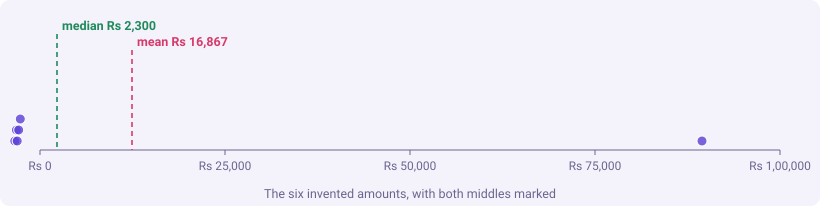

In [9]:
invented = [1900, 2100, 2200, 2400, 2600]          # invented orders, for the mechanism only
invented_mean_before = sum(invented) / len(invented)
invented_median_before = sorted(invented)[2]

invented_plus = sorted(invented + [90000])          # one invented large order added
invented_mean_after = sum(invented_plus) / len(invented_plus)
invented_median_after = (invented_plus[2] + invented_plus[3]) / 2

kit.table(["invented records", "mean", "median"],
          [("five invented orders", kit.rupees(invented_mean_before), kit.rupees(invented_median_before)),
           ("the same five plus one invented Rs 90,000 order", kit.rupees(round(invented_mean_after)), kit.rupees(invented_median_after))],
          caption="Invented numbers: what one large order does to each middle")
kit.columns(["five invented orders", "plus one invented large order"],
            [("mean", [round(invented_mean_before), round(invented_mean_after)]),
             ("median", [invented_median_before, round(invented_median_after)])],
            fmt=kit.rupees, width=560, title="Invented records: the mean jumps, the median steps")
kit.strip(invented_plus, markers=[("median", invented_median_after, "good"), ("mean", round(invented_mean_after), "bad")],
          title="The six invented amounts, with both middles marked")

**What happened.** The answer is d. On the invented records the mean jumps from Rs 2,240 to Rs 16,867
because every rupee of the large order enters the total, while the median moves Rs 100, from Rs 2,200
to Rs 2,300, because the large order only pushes the middle along by one place. The same thing
happened in Kalpa's 30 orders, and your two empty cells show which order did it.

In [10]:
kit.check("on invented records the median moves by Rs 100", invented_median_after - invented_median_before == 100,
          f"{kit.rupees(invented_median_before)} to {kit.rupees(invented_median_after)}")
kit.check("on invented records the mean moves by more than Rs 14,000",
          invented_mean_after - invented_mean_before > 14000,
          f"{kit.rupees(invented_mean_before)} to {kit.rupees(round(invented_mean_after))}")

## 4. The median holds under every definition, and it prices a first order

Round 1 gave sales three definitions and round 2 showed every leaf moving with them. The room's
harder variant asks the same of the typical order: compute the mean and the median on booked, not
cancelled and delivered orders, and say what a first order is worth to the acquisition case.

The median rule for any count: sort, then take the middle value when the count is odd, or halfway
between the two middle values when it is even.

**Predict before you run.** On delivered orders only, the mean rises. What does the median do?

- a) It rises by the same amount as the mean.
- b) It moves by less than Rs 200.
- c) It doubles, since the cheaper orders were the ones returned.
- d) It becomes equal to the mean.

definition,orders,mean,median,mean over median
booked,30,"Rs 18,160","Rs 2,205",8.2
not cancelled,26,"Rs 20,606","Rs 2,100",9.8
delivered,21,"Rs 24,800","Rs 2,060",12.0


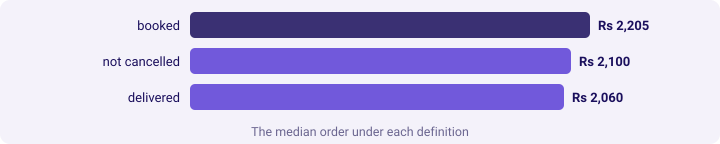

In [11]:
definitions = {
    "booked": {"delivered", "returned", "cancelled"},
    "not cancelled": {"delivered", "returned"},
    "delivered": {"delivered"},
}
middles = {}
for name in definitions:
    kept = []
    for order in ORDERS:
        if order["status"] in definitions[name]:
            kept.append(int(order["amount"]))
    kept.sort()
    n = len(kept)
    if n % 2 == 1:
        middle = kept[n // 2]
    else:
        middle = (kept[n // 2 - 1] + kept[n // 2]) / 2
    middles[name] = {"orders": n, "mean": sum(kept) / n, "median": middle}

kit.table(["definition", "orders", "mean", "median", "mean over median"],
          [(name, v["orders"], kit.rupees(round(v["mean"])), kit.rupees(v["median"]), f'{v["mean"] / v["median"]:.1f}')
           for name, v in middles.items()],
          caption="Both middles under each definition of sales")
kit.bars([(name, middles[name]["median"]) for name in middles], fmt=kit.rupees, lit=(0,),
         title="The median order under each definition")

**What happened.** The answer is b. The median is Rs 2,205 booked, Rs 2,100 not cancelled and
Rs 2,060 delivered, a spread of Rs 145. The mean runs from Rs 18,160 to Rs 24,800 over the same
three definitions, because removing ordinary orders leaves the same large order carrying a bigger
share of a smaller count. A number that swings by Rs 6,640 when the definition changes cannot be
the one Meera plans on.

The acquisition case needs the value of a new customer's order. The chart below counts how many
orders at the median it takes to bring in what the mean promised from one.

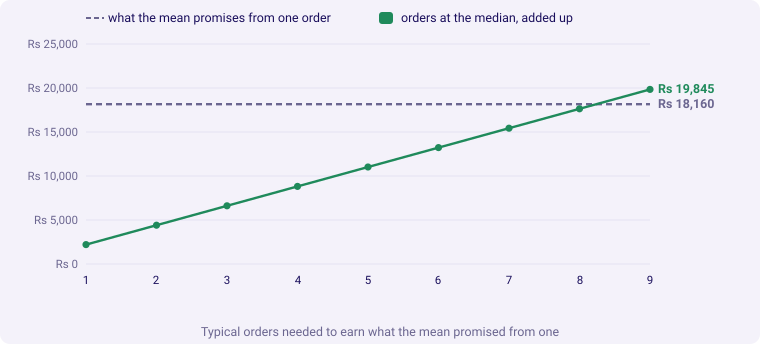

8.2 typical orders earn what marketing's model credits to one first order


In [12]:
typical = middles["booked"]["median"]
promised = middles["booked"]["mean"]
orders_axis = list(range(1, 10))
kit.line([str(k) for k in orders_axis],
         [("what the mean promises from one order", [round(promised)] * len(orders_axis), "plan"),
          ("orders at the median, added up", [round(typical * k) for k in orders_axis], "good")],
         fmt=kit.rupees, title="Typical orders needed to earn what the mean promised from one")
needed = promised / typical
print(f"{needed:.1f} typical orders earn what marketing's model credits to one first order")

In [13]:
kit.check("booked median is Rs 2,205", middles["booked"]["median"] == 2205)
kit.check("delivered median is Rs 2,060", middles["delivered"]["median"] == 2060)
kit.check("the medians stay within Rs 200 of each other",
          max(v["median"] for v in middles.values()) - min(v["median"] for v in middles.values()) < 200)
kit.check("the means spread by more than Rs 6,000",
          max(v["mean"] for v in middles.values()) - min(v["mean"] for v in middles.values()) > 6000)
kit.check("about eight typical orders match one mean order", 8 <= needed <= 8.5, f"{needed:.1f}")

For Meera this settles the typical order: about Rs 2,205, and about Rs 2,060 if she plans on
delivered orders. A new customer brings in about one eighth of what marketing's model credits to a
first order, so the payback on the Rs 12 crore needs about eight times as many orders as the slide
implies. With 16 of 23 customers buying only once in the quarter, those extra orders are exactly the
frequency branch round 2 found live.

### In the interview

**[S] Mean or median for order value, and why?** "The median when a few large orders can pull the
mean, which in retail is almost always, because business and bulk buyers sit in the same file as
households. I would report both, with the count of orders above the mean, because the gap between
them is itself a finding: on Kalpa's quarter the mean was Rs 18,160, the median Rs 2,205, and 29 of
30 orders sat below the mean. The mean still has its job: mean times count gives revenue, so for
totals and forecasts it is the right number."

**[S] The mean order is Rs 18,160 and the median Rs 2,205; what do you tell the business about its
orders?** "That a typical order is about Rs 2,205, and that one or a few very large orders lift the
mean to eight times that. I would sort the orders, name what sits at the top, and ask whether it is
a different kind of customer that deserves its own line in the plan. Anything priced per order, an
acquisition payback or a delivery cost, should be priced on the median."

**[D] Marketing wants budget for acquisition; what would you check before agreeing it is the right
branch, and how would you say no?** "I would check three things on the same window: how many
customers came back, what a typical order is worth, and whether the base the target was set on is
the right definition of sales. Here 16 of 23 customers bought once and 7 came back, and a typical
order is Rs 2,205, far below the Rs 18,160 the case assumed. I would not say no to acquisition; I
would say not yet, and not first: open frequency, where the customers already exist, and bring the
acquisition case back with a first-order value on the median and a second quarter to compare."

### Depth: how far does one order have to go before the mean stops meaning anything?

The cell below grows one **invented** order from Rs 2,600 to Rs 90,000 alongside the same five
invented orders and recomputes both middles each time. It also shows the median's limit: it
describes a typical order and says nothing about the total.

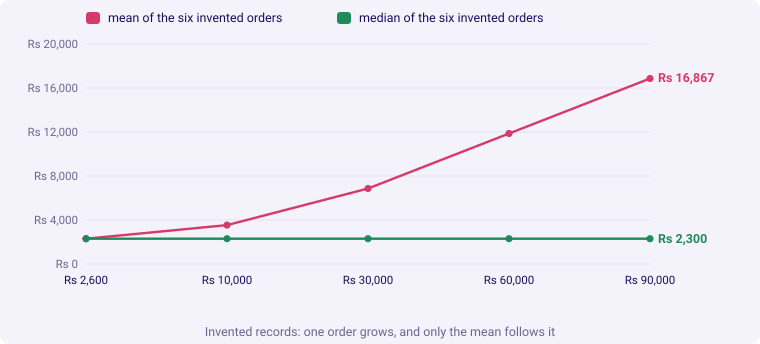

median x 30 orders = Rs 66,150 against booked revenue of Rs 5,44,810


In [14]:
sizes = [2600, 10000, 30000, 60000, 90000]          # the invented large order, growing
means, medians = [], []
for size in sizes:
    six = sorted(invented + [size])
    means.append(round(sum(six) / 6))
    medians.append(round((six[2] + six[3]) / 2))
kit.line([kit.rupees(s) for s in sizes],
         [("mean of the six invented orders", means, "bad"), ("median of the six invented orders", medians, "good")],
         fmt=kit.rupees, title="Invented records: one order grows, and only the mean follows it")
print("median x 30 orders =", kit.rupees(median * 30), "against booked revenue of", kit.rupees(total))
kit.check("the invented median never moves past Rs 2,500", max(medians) <= 2500, medians)
kit.check("median times count does not rebuild revenue", round(median * 30) != total)

The median is the honest answer to "what does a typical order look like?", and the mean is the only
one that multiplies back to revenue. A careful analyst reports the median for the typical order,
keeps the mean for the total, and says which order separates them.

## What this round established

What we now know,The evidence
"The mean is total over count, and one order can drag it","Rs 18,160, with 29 of 30 orders below it"
The median is the typical order,"Rs 2,205, about one eighth of the mean"
The median holds when the definition changes,"Rs 2,205 booked, Rs 2,060 delivered"
"A first order is worth about Rs 2,205 to the acquisition case",8.2 typical orders to match one mean order


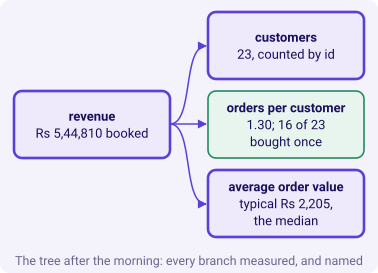

In [15]:
kit.table(["What we now know", "The evidence"],
          [("The mean is total over count, and one order can drag it", "Rs 18,160, with 29 of 30 orders below it"),
           ("The median is the typical order", "Rs 2,205, about one eighth of the mean"),
           ("The median holds when the definition changes", "Rs 2,205 booked, Rs 2,060 delivered"),
           ("A first order is worth about Rs 2,205 to the acquisition case", "8.2 typical orders to match one mean order")],
          caption="Round 3: the typical order")
kit.driver_tree({"label": "revenue", "note": "Rs 5,44,810 booked", "kind": "known", "children": [
    {"label": "customers", "note": "23, counted by id", "kind": "known"},
    {"label": "orders per customer", "note": "1.30; 16 of 23 bought once", "kind": "good"},
    {"label": "average order value", "note": "typical Rs 2,205, the median", "kind": "known"}]},
    title="The tree after the morning: every branch measured, and named")

In [16]:
kit.check_summary()
print("Next: the afternoon's escalated case, where Meera asks which branch to open first and what "
      "one window of data cannot show.")

Next: the afternoon's escalated case, where Meera asks which branch to open first and what one window of data cannot show.
